# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Diandra Puspo Negoro
- **Email:** dyandrapusponegoro@gmail.com
- **ID Dicoding:** pediiiasure

## Menentukan Pertanyaan Bisnis

- **Tren Kualitas Udara**: Bagaimana pola konsentrasi PM2.5 di Beijing berubah dari tahun 2013 hingga 2017? Kapan polusi paling parah terjadi (tahunan, musiman, dan harian)?
- **Pengaruh Cuaca:** Seberapa besar pengaruh kondisi cuaca (kecepatan angin, suhu, kelembapan) terhadap konsentransi PM2.5? Faktor cuaca apa yang paling dominan?
- **Analisis Lanjutan:** Bagaimana pengelompokkan stasiun-stasiun pemantauan di Beijing berdasarkan profil polusi dan kondisi cuacanya, serta apa karakteristik yang membedakan setiap kelompok tersebut?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**INFORMASI DATASET**



## Data Wrangling

### Gathering Data

In [2]:
# Memuat tabel aotizhongxin
aotizhongxin_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
aotizhongxin_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
# Memuat tabel changping
changping_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv")
changping_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [4]:
# Memuat tabel dingling
dingling_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv")
dingling_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [5]:
# Memuat tabel dongsi
dongsi_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv")
dongsi_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [6]:
# Memuat tabel guanyuan
guanyuan_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv")
guanyuan_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [7]:
# Memuat tabel gucheng
gucheng_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv")
gucheng_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [8]:
# Memuat tabel huairou
huairou_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv")
huairou_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [9]:
# Memuat tabel nongzhanguan
nongzhanguan_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv")
nongzhanguan_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [10]:
# Memuat tabel shunyi
shunyi_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv")
shunyi_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [11]:
# Memuat tabel tiantan
tiantan_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv")
tiantan_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [12]:
# Memuat tabel wanliu
wanliu_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv")
wanliu_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [13]:
# Memuat tabel wanshouxigong
wanshouxigong_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv")
wanshouxigong_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


**Insight:**
- Dataset terdiri dari 12 file CSV yang terpisah, masing-masing mewakili satu stasiun pemamntauan kualitas udara di beijing
- Semua dataset memiliki struktur yang serupa, dengan kolom terbagi menjadi tiga kelompok: waktu (year, month, day, hour), polutan (PM2.5, PM10, SO2, NO2, CO, O3), dan cuaca (TEMP, PRES, DEWP, RAIN, wd, WSPM)
- Periode 1 Maret 2013 - 28 Februari 2017, pengukuran dilakukan per jam selama 4 tahun


### Assessing Data

In [14]:
# Menilai data aotizhongxin
aotizhongxin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [15]:
print("Jumlah duplikasi:", aotizhongxin_df.duplicated().sum())

Jumlah duplikasi: 0


In [16]:
aotizhongxin_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


In [17]:
# Menilai data changping
changping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [18]:
print("Jumlah duplikasi:", changping_df.duplicated().sum())

Jumlah duplikasi: 0


In [19]:
changping_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,310.000000,226.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


In [20]:
# Menilai tabel dingling
dingling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [21]:
print("Jumlah duplikasi:", dingling_df.duplicated().sum())

Jumlah duplikasi: 0


In [22]:
dingling_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,881.000000,905.000000,156.000000,205.000000,10000.000000,500.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


In [23]:
# Menilai tabel dongsi
dongsi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [24]:
print("Jumlah duplikasi:", dongsi_df.duplicated().sum())

Jumlah duplikasi: 0


In [25]:
dongsi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,737.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


In [26]:
# Menilai tabel guanyuan
guanyuan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [27]:
print("Jumlah duplikasi:", guanyuan_df.duplicated().sum())

Jumlah duplikasi: 0


In [28]:
guanyuan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,680.000000,999.000000,293.000000,270.000000,10000.000000,415.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


In [29]:
# Menilai tabel gucheng
gucheng_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [30]:
print("Jumlah duplikasi:", gucheng_df.duplicated().sum())

Jumlah duplikasi: 0


In [31]:
gucheng_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,35022.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,1.343310
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,1.151064
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,0.600000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,1.000000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,1.800000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,770.000000,994.000000,500.000000,276.000000,10000.000000,450.000000,41.600000,1038.100000,27.400000,41.900000,12.000000


In [32]:
# Menilai tabel huairou
huairou_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34111 non-null  float64
 6   PM10     34287 non-null  float64
 7   SO2      34084 non-null  float64
 8   NO2      33425 non-null  float64
 9   CO       33642 non-null  float64
 10  O3       33913 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35011 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35009 non-null  float64
 15  wd       34762 non-null  object 
 16  WSPM     35015 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [33]:
print("Jumlah duplikasi:", huairou_df.duplicated().sum())

Jumlah duplikasi: 0


In [34]:
huairou_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34111.000000,34287.000000,34084.000000,33425.000000,33642.000000,33913.000000,35013.000000,35011.000000,35011.000000,35009.000000,35015.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,69.626367,91.482690,12.121553,32.497250,1022.554545,59.824713,12.445426,1007.598568,2.238619,0.067940,1.652021
std,10122.249256,1.177213,3.448752,8.800218,6.922285,71.224916,83.289578,18.896912,26.489531,898.738241,54.605746,11.751103,10.022101,14.052541,0.849046,1.199143
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,28.000000,2.000000,12.000000,400.000000,18.000000,2.100000,999.300000,-9.600000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,47.000000,69.000000,4.000000,25.000000,800.000000,49.000000,13.600000,1007.300000,2.700000,0.000000,1.300000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,98.000000,131.000000,14.000000,46.000000,1300.000000,83.000000,22.300000,1015.500000,15.300000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,762.000000,993.000000,315.000000,231.000000,10000.000000,444.000000,40.300000,1036.500000,29.100000,45.900000,12.900000


In [35]:
# Menilai tabel nongzhanguan
nongzhanguan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [36]:
print("Jumlah duplikasi:", nongzhanguan_df.duplicated().sum())

Jumlah duplikasi: 0


In [37]:
nongzhanguan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,844.000000,995.000000,257.000000,273.000000,10000.000000,390.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


In [38]:
# Menilai tabel shunyi
shunyi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34151 non-null  float64
 6   PM10     34516 non-null  float64
 7   SO2      33768 non-null  float64
 8   NO2      33699 non-null  float64
 9   CO       32886 non-null  float64
 10  O3       33575 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35013 non-null  float64
 13  DEWP     35010 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34581 non-null  object 
 16  WSPM     35020 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [39]:
print("Jumlah duplikasi:", shunyi_df.duplicated().sum())

Jumlah duplikasi: 0


In [40]:
shunyi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34151.000000,34516.000000,33768.000000,33699.000000,32886.000000,33575.000000,35013.000000,35013.000000,35010.000000,35013.000000,35020.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.491602,98.737026,13.572039,43.908865,1187.063979,55.201321,13.387969,1013.061938,2.465036,0.061094,1.807533
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.231739,89.143718,19.572068,30.996828,1156.374102,54.873726,11.483588,10.177339,13.726622,0.761668,1.287817
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,988.000000,-36.000000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,19.000000,31.000000,2.000000,19.000000,400.000000,10.000000,3.000000,1004.700000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,77.000000,5.000000,37.000000,800.000000,43.000000,14.400000,1012.700000,3.100000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,138.000000,17.000000,62.000000,1500.000000,77.000000,23.200000,1021.000000,15.100000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,941.000000,999.000000,239.000000,258.000000,10000.000000,351.716400,40.600000,1042.800000,27.500000,37.300000,12.800000


In [41]:
# Menilai tabel tiantan
tiantan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [42]:
print("Jumlah duplikasi:", tiantan_df.duplicated().sum())

Jumlah duplikasi: 0


In [43]:
tiantan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34387.000000,34467.000000,33946.000000,34320.000000,33938.000000,34221.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.921384,89.700157,20.144631,31.946224,1170.593297,59.081528,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.571200,2.000000,100.000000,0.428400,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,41.000000,3.000000,28.000000,500.000000,8.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,7.000000,47.000000,900.000000,40.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,113.000000,144.000000,17.000000,71.000000,1600.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,821.000000,988.000000,273.000000,241.000000,10000.000000,674.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


In [44]:
# Menilai tabel wanliu
wanliu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34682 non-null  float64
 6   PM10     34780 non-null  float64
 7   SO2      34489 non-null  float64
 8   NO2      33994 non-null  float64
 9   CO       33252 non-null  float64
 10  O3       32957 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34941 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [45]:
print("Jumlah duplikasi:", wanliu_df.duplicated().sum())

Jumlah duplikasi: 0


In [46]:
wanliu_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34682.000000,34780.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.374716,110.464618,18.376481,65.258789,1319.353513,48.873614,13.428865,1011.097536,3.266588,0.068263,1.501215
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.905568,92.795065,22.609648,37.996088,1268.114331,55.111740,11.346931,10.355247,13.678060,0.896726,1.104472
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.642400,100.000000,0.214200,-15.800000,985.900000,-34.900000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,4.000000,36.000000,500.000000,4.000000,3.200000,1002.500000,-8.100000,0.000000,0.800000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,88.000000,10.000000,60.000000,900.000000,32.000000,14.300000,1010.800000,4.000000,0.000000,1.200000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,153.000000,23.000000,88.000000,1600.000000,73.000000,22.900000,1019.400000,15.800000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,957.000000,951.000000,282.000000,264.000000,10000.000000,364.000000,40.500000,1040.300000,28.500000,72.500000,11.200000


In [47]:
# Menilai tabel wanshouxigong
wanshouxigong_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34368 non-null  float64
 6   PM10     34580 non-null  float64
 7   SO2      34395 non-null  float64
 8   NO2      34310 non-null  float64
 9   CO       33767 non-null  float64
 10  O3       33986 non-null  float64
 11  TEMP     35045 non-null  float64
 12  PRES     35045 non-null  float64
 13  DEWP     35045 non-null  float64
 14  RAIN     35045 non-null  float64
 15  wd       34985 non-null  object 
 16  WSPM     35051 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [48]:
print("Jumlah duplikasi:", wanshouxigong_df.duplicated().sum())

Jumlah duplikasi: 0


In [49]:
wanshouxigong_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,10122.249256,1.177213,3.448752,8.800218,6.922285,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


**Insight:**
- Semua stasiun memiliki struktur tabel yang sama
- Tidak ditemukan duplikasi data pada seluruh stasiun
- Terdapat missing value pada seluruh kolom polutan dan sebagian kolom cuaca. Kolom dengan missing value terbanyak adalah CO, diikuti dengan O3 dan NO2. Stasiun dongsi memiliki missing value CO tertinggi.
- Dari statistik deskriptif, PM2.5 berkisar antara 2-999 µg/m³ dengan rata-rata 79.79 µg/m³ jauh melampaui batas aman WHO (15 µg/m³ rata-rata tahunan)
- PM10 dengan rata-rata 104.60 µg/m³
- CO memiliki standar deviasi tertinggi, hingga 1160.18, menandakan banyak kejadian polusi ekstrem
- Stasiun Dongsi memiliki rata-rata PM2.5 tertinggi (86.2 µg/m³),
  diikuti Wanshouxigong (85.0 µg/m³) dan Nongzhanguan (84.8 µg/m³).
-  Stasiun Dingling memiliki rata-rata PM2.5 terendah (66.0 µg/m³),
  diikuti Changping (71.1) dan Huairou (69.6)

### Cleaning Data

In [50]:
# Menggabungkan seluruh stasiun menjadi satu DataFrame
df = pd.concat([
    aotizhongxin_df, changping_df, dingling_df, dongsi_df,
    guanyuan_df, gucheng_df, huairou_df, nongzhanguan_df,
    shunyi_df, tiantan_df, wanliu_df, wanshouxigong_df
], ignore_index=True)

print(f"Total baris: {len(df):,}")
print(f"Total kolom: {df.shape[1]}")
df.head()

Total baris: 420,768
Total kolom: 18


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [51]:
# Hapus kolom No
df.drop('No', axis=1, inplace=True)

In [52]:
# Mengecek missing value pada seluruh dataset gabungan
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})

missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)

,Jumlah Missing,Persentase (%)
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
PRES,393,0.09
TEMP,398,0.09


In [53]:
kolom_polutan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

for col in kolom_polutan:
    df[col] = df.groupby('station')[col].transform(
        lambda x: x.ffill().bfill()
    )

print("Missing value kolom polutan setelah cleaning:")
print(df[kolom_polutan].isnull().sum())

Missing value kolom polutan setelah cleaning:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
dtype: int64


In [54]:
kolom_cuaca = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in kolom_cuaca:
    df[col] = df.groupby('station')[col].transform(
        lambda x: x.ffill().bfill()
    )

print("Missing value kolom cuaca setelah cleaning:")
print(df[kolom_cuaca].isnull().sum())

Missing value kolom cuaca setelah cleaning:
TEMP    0
PRES    0
DEWP    0
RAIN    0
WSPM    0
dtype: int64


In [55]:
df['wd'] = df.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print("Missing value kolom 'wd' (arah angin) setelah cleaning:")
print(df['wd'].isnull().sum())

Missing value kolom 'wd' (arah angin) setelah cleaning:
0


**Insight:**
- Semua missing value pada kolom polutan dan cuaca berhasil ditangani menggunakan metode forward-fill dan backward-fill (ffill().bfill()) berdasarkan masing-masing stasiun.
- Missing value pada kolom 'wd' (arah angin) juga berhasil diisi menggunakan modus per stasiun.
- Setelah pembersihan, dataset tidak memiliki missing value sama sekali
- Menghapus kolom No

## Exploratory Data Analysis (EDA)

### Explore...

In [56]:
# Rata-rata PM2.5 per tahun (semua stasiun)
yearly_mean_pm25 = df.groupby('year')['PM2.5'].mean().round(2)
yearly_mean_pm25

,PM2.5
year,
2013,80.06
2014,86.66
2015,79.51
2016,72.36
2017,92.57


In [57]:
# Rata-rata PM2.5 per bulan (pola musiman)
monthly_mean_pm25 = df.groupby('month')['PM2.5'].mean().reset_index().round(2)
monthly_mean_pm25['month'] = monthly_mean_pm25['month'].map({
    1:'Januari', 2:'Februari', 3:'Maret', 4:'April',
    5:'Mei', 6:'Juni', 7:'Juli', 8:'Agustus',
    9:'September', 10:'Oktober', 11:'November', 12:'Desember'
})
monthly_mean_pm25

,month,PM2.5
0,Januari,94.02
1,Februari,89.16
2,Maret,94.76
3,April,73.85
4,Mei,64.19
5,Juni,68.96
6,Juli,71.97
7,Agustus,53.65
8,September,61.40
9,Oktober,92.21


In [58]:
# Rata-rata PM2.5 per jam dalam sehari (pola harian)
hourly_mean_pm25 = df.groupby('hour').agg(
    rata_rata_pm25=('PM2.5', 'mean'),
    pm25_max=('PM2.5', 'max'),
    pm25_min=('PM2.5', 'min')
).round(2).reset_index()

hourly_mean_pm25.columns = ['Jam', 'Rata-rata PM2.5', 'PM2.5 Maksimum', 'PM2.5 Minimum']

print("Jam dengan PM2.5 tertinggi:")
print(hourly_mean_pm25.loc[hourly_mean_pm25['Rata-rata PM2.5'].idxmax()])
print()
print("Jam dengan PM2.5 terendah:")
print(hourly_mean_pm25.loc[hourly_mean_pm25['Rata-rata PM2.5'].idxmin()])
print()
hourly_mean_pm25

Jam dengan PM2.5 tertinggi:
Jam                 22.00
Rata-rata PM2.5     89.23
PM2.5 Maksimum     770.00
PM2.5 Minimum        3.00
Name: 22, dtype: float64

Jam dengan PM2.5 terendah:
Jam                  7.00
Rata-rata PM2.5     73.81
PM2.5 Maksimum     712.00
PM2.5 Minimum        3.00
Name: 7, dtype: float64



,Jam,Rata-rata PM2.5,PM2.5 Maksimum,PM2.5 Minimum
0,0,87.96,809.0,3.0
1,1,87.10,881.0,3.0
2,2,85.09,999.0,3.0
3,3,82.55,857.0,3.0
4,4,79.82,801.0,2.0
5,5,76.88,770.0,2.0
6,6,74.65,720.0,3.0
7,7,73.81,712.0,3.0
8,8,74.82,610.0,3.0
9,9,76.43,640.0,3.0


**Insight**
- Konsentrasi PM2.5 mengalami kenaikan di tahun 2014, kemudian turun hingga mencapaititik terendah di tahun 2016, namun kembali melonjak di tahun 2017. Seluruh nilai masih berada jauh di atas batas aman WHO (15 µg/m³).
- PM2.5 tertinggi terjadi di bulan Desember dan terendah di bulan Agustus
- PM2.5 mencapai puncak pada jam 22 dan minimun di jam 7. Kondisi atmosfer malam hari menghambat dispersi polutan sehingga polutan terakumulasi.

In [59]:
# Korelasi variabel cuaca terhadap PM2.5
kolom_cuaca = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
korelasi_cuaca_pm25 = df[kolom_cuaca + ['PM2.5']].corr()['PM2.5'].drop('PM2.5')
korelasi_cuaca_pm25.sort_values(ascending=True)

,PM2.5
WSPM,-0.269565
TEMP,-0.130454
RAIN,-0.014153
PRES,0.019145
DEWP,0.112820


In [60]:
# Mengelompokkan kecepatan angin ke dalam kategori
df['wspm_cat'] = pd.cut(
    df['WSPM'],
    bins=[0, 1, 2, 4,14],
    labels=['Calm (0-1 m/s)', 'Light (1-2 m/s)', 'Moderate (2-4 m/s)', 'Strong (>4 m/s)']
)

# Rata-rata PM2.5 per kategori kecepatan angin
wspm_mean_pm25 = df.groupby('wspm_cat', observed=True).agg(
    rata_rata_pm25=('PM2.5', 'mean'),
    pm25_max=('PM2.5', 'max'),
    pm25_min=('PM2.5', 'min'),
    jumlah_data=('PM2.5', 'count')
).round(2).reset_index()

wspm_mean_pm25.columns = ['Kategori Angin', 'Rata-rata PM2.5',
                     'PM2.5 Maksimum', 'PM2.5 Minimum', 'Jumlah Data']
wspm_mean_pm25

,Kategori Angin,Rata-rata PM2.5,PM2.5 Maksimum,PM2.5 Minimum,Jumlah Data
0,Calm (0-1 m/s),101.73,957.0,3.0,124312
1,Light (1-2 m/s),84.90,999.0,2.0,164818
2,Moderate (2-4 m/s),54.10,844.0,2.0,95370
3,Strong (>4 m/s),29.21,592.0,2.0,25148


In [61]:
# Rata-rata PM2.5 per arah angin
wind_mean_pm25 = df.groupby('wd')['PM2.5'].mean().round(2).reset_index()
wind_mean_pm25.columns = ['Arah Angin', 'Rata-rata PM2.5']
wind_mean_pm25

,Arah Angin,Rata-rata PM2.5
0,E,102.05
1,ENE,97.96
2,ESE,102.30
3,N,67.75
4,NE,86.39
5,NNE,72.06
6,NNW,54.56
7,NW,52.30
8,S,89.55
9,SE,96.61


**Insight:**
- Kecepatan angin (WSPM) memiliki korelasi negatif tersebut terkuat dengan PM2.5 (-0.270), diikuti suhu TEMP (-0.130). Curah hujan (RAIN) hampir tidak berpengaruh karena Beijing jarang terjadi hujan.
- Semakin kencang angin, semakin rendah konsentrasi PM2.5 secara konsisten
- Arah angin memberikan pengaruh kualitas udara secara signifikan. Angin yang berhembus dari sektor timur membawa konsentrasi PM2.5 tertinggi mengindikasikan keberadaan sumber polusi besar seperti kawasan industri di sektor tersebut

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola konsetrasi PM2.5 di Beijing dari tahun 2013 hingga 2017?

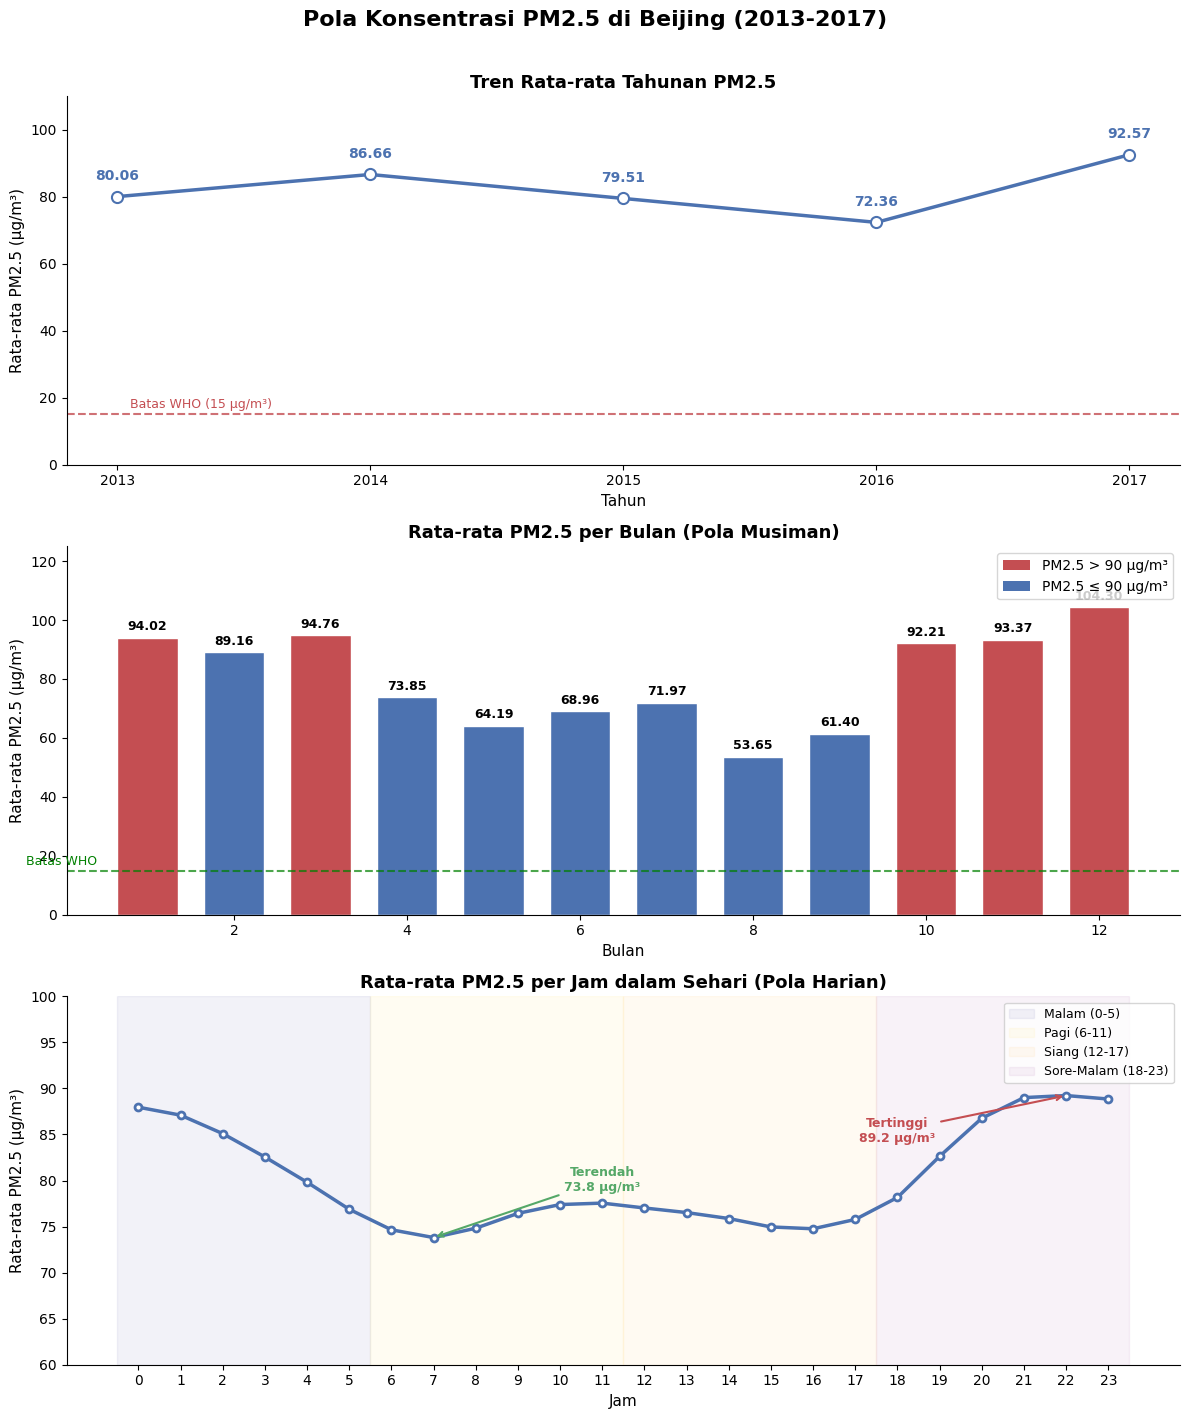

In [62]:
from ast import FunctionType
# Menyiapkan data
yearly_mean_pm25 = df.groupby('year')['PM2.5'].mean().reset_index()
monthly_mean_pm25 = df.groupby('month')['PM2.5'].mean().reset_index()
hourly_mean_pm25 = df.groupby('hour')['PM2.5'].mean().reset_index()

month = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
color_bar = ['#C44E52' if v > 90 else '#4C72B0' for v in monthly_mean_pm25['PM2.5']]

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Pola Konsentrasi PM2.5 di Beijing (2013-2017)',
             fontsize=16, fontweight='bold', y=1.01)

# Plot Tren Tahunan
ax1 = axes[0]
ax1.plot(yearly_mean_pm25['year'], yearly_mean_pm25['PM2.5'], marker='o', linestyle='-', color='#4C72B0',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=1.5)
for _, row in yearly_mean_pm25.iterrows():
    ax1.annotate(f"{row['PM2.5']:.2f}",
     xy=(row['year'], row['PM2.5']),
     xytext=(0, 12), textcoords='offset points',
     ha='center', fontsize=10, fontweight='bold', color='#4C72B0')

ax1.axhline(y=15, color='#C44E52', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(2013.05, 17, 'Batas WHO (15 µg/m³)', color='#C44E52', fontsize=9)
ax1.set_title('Tren Rata-rata Tahunan PM2.5', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tahun', fontsize=11)
ax1.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax1.set_xticks(yearly_mean_pm25['year'])
ax1.set_ylim(0, 110)
sns.despine(ax=ax1)

# Plot Musiman
ax2 = axes[1]
bars = ax2.bar(monthly_mean_pm25['month'], monthly_mean_pm25['PM2.5'],
               color=color_bar, edgecolor='white', width=0.7)

for bar, val in zip (bars, monthly_mean_pm25['PM2.5']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f"{val:.2f}", ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax2.axhline(y=15, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(-0.4, 17, 'Batas WHO', color='green', fontsize=9)
ax2.set_title('Rata-rata PM2.5 per Bulan (Pola Musiman)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax2.set_ylim(0, 125)

from matplotlib.patches import Patch
legend_elem = [Patch(facecolor='#C44E52', label='PM2.5 > 90 µg/m³'),
               Patch(facecolor='#4C72B0', label='PM2.5 ≤ 90 µg/m³')]
ax2.legend(handles=legend_elem, loc='upper right')
sns.despine(ax=ax2)

# Plot Pola Harian
ax3 = axes[2]
ax3.plot(hourly_mean_pm25['hour'], hourly_mean_pm25['PM2.5'],
         alpha=0.15, color='#4C72B0')
ax3.plot(hourly_mean_pm25['hour'], hourly_mean_pm25['PM2.5'],
         marker='o', linewidth=2.5, markersize=5,
         markerfacecolor='white', markeredgewidth=2,
         color='#4C72B0')
# Tandai titik tertinggi
idx_max = hourly_mean_pm25['PM2.5'].idxmax()
idx_min = hourly_mean_pm25['PM2.5'].idxmin()

ax3.annotate(f"Tertinggi\n{hourly_mean_pm25['PM2.5'][idx_max]:.1f} µg/m³",
             xy=(hourly_mean_pm25['hour'][idx_max], hourly_mean_pm25['PM2.5'][idx_max]),
             xytext=(hourly_mean_pm25['hour'][idx_max] - 4, hourly_mean_pm25['PM2.5'][idx_max] - 5),
             arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.5),
             fontsize=9, fontweight='bold', color='#C44E52',
             ha='center')

ax3.annotate(f"Terendah\n{hourly_mean_pm25['PM2.5'][idx_min]:.1f} µg/m³",
             xy=(hourly_mean_pm25['hour'][idx_min], hourly_mean_pm25['PM2.5'][idx_min]),
             xytext=(hourly_mean_pm25['hour'][idx_min] + 4, hourly_mean_pm25['PM2.5'][idx_min] + 5),
             arrowprops=dict(arrowstyle='->', color='#55A868', lw=1.5),
             fontsize=9, fontweight='bold', color='#55A868',
             ha='center')

ax3.axvspan(-0.5,  5.5, alpha=0.05, color='navy',   label='Malam (0-5)')
ax3.axvspan( 5.5, 11.5, alpha=0.05, color='gold',   label='Pagi (6-11)')
ax3.axvspan(11.5, 17.5, alpha=0.05, color='orange', label='Siang (12-17)')
ax3.axvspan(17.5, 23.5, alpha=0.05, color='purple', label='Sore-Malam (18-23)')

ax3.set_title('Rata-rata PM2.5 per Jam dalam Sehari (Pola Harian)',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Jam', fontsize=11)
ax3.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=11)
ax3.set_xticks(range(0, 24))
ax3.set_ylim(60, 100)
ax3.legend(loc='upper right', fontsize=9)
sns.despine(ax=ax3)

plt.tight_layout()
plt.show()

**Insight:**
- Konsentrasi PM2.5 mengalami penurunan dari puncak 2014 (86.66) ke titik terendah 2016 (72.36) , namun melonjak kembali di 2017 mencapai titik tertinggi (92.57 µg/m³). Seluruh nilai masih berada di atas batas aman WHO (15 µg/m³)
- Polusi paling parah terjadi sekitar bulan november - desember (104.30 µg/m³) hamoir dua kali lipat bulan agustus (53.65 µg/m³) yang merupakan bulan terbersih
- PM2.5 mencapai puncak pada jam 22 (89.02 µg/m³) dan minimum pada jam 07
  (73.8 µg/m³), malam hari lebih tercemar karena kondisi atmosfer
  menghambat dispersi polutan.

### Pertanyaan 2: Seberapa besar pengaruh kondisi cuaca terhadap konsetrasi PM2.5

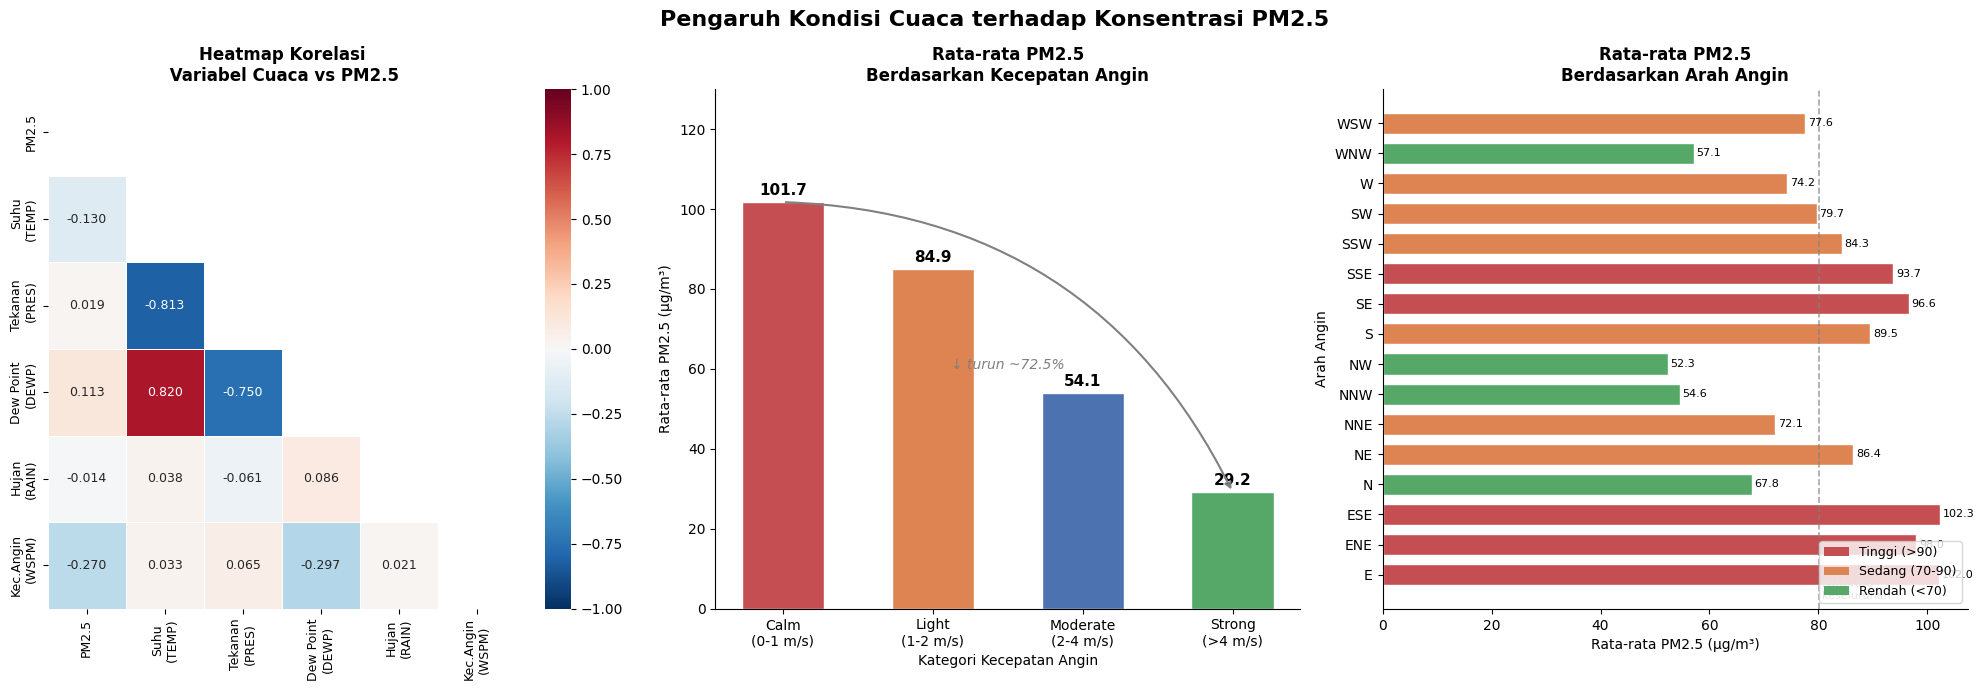

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Pengaruh Kondisi Cuaca terhadap Konsentrasi PM2.5',
             fontsize=16, fontweight='bold')

# Plot Heatmap Korelasi
ax1 = axes[0]
corr_labels = ['PM2.5', 'Suhu\n(TEMP)', 'Tekanan\n(PRES)',
               'Dew Point\n(DEWP)', 'Hujan\n(RAIN)', 'Kec.Angin\n(WSPM)']

corr_matrix = df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5, ax=ax1, mask=mask, annot_kws={'size': 9})

ax1.set_title('Heatmap Korelasi\n Variabel Cuaca vs PM2.5', fontsize=12, fontweight='bold')
plt.setp(ax1.get_xticklabels(), fontsize=9)
plt.setp(ax1.get_yticklabels(), fontsize=9)

# Plot PM2.5 per Kecepatan Angin
ax2=axes[1]
wspm_labels  = ['Calm\n(0-1 m/s)', 'Light\n(1-2 m/s)',
                'Moderate\n(2-4 m/s)', 'Strong\n(>4 m/s)']
wspm_vals    = wspm_mean_pm25['Rata-rata PM2.5'].values
colors_wind  = ['#C44E52', '#DD8452', '#4C72B0', '#55A868']

bars = ax2.bar(wspm_labels, wspm_vals, color=colors_wind,
               edgecolor='white', width=0.55)

for bar, val in zip(bars, wspm_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Anotasi penurunan
ax2.annotate('',
             xy=(3, wspm_vals[3]),
             xytext=(0, wspm_vals[0]),
             arrowprops=dict(arrowstyle='->', color='gray',
                             lw=1.5, connectionstyle='arc3,rad=-0.3'))
ax2.text(1.5, 60, '↓ turun ~72.5%', ha='center',
         fontsize=10, color='gray', style='italic')

ax2.set_title('Rata-rata PM2.5\nBerdasarkan Kecepatan Angin',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Kategori Kecepatan Angin', fontsize=10)
ax2.set_ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=10)
ax2.set_ylim(0, 130)
sns.despine(ax=ax2)

# Plot PM2.5 per Arah Angin
ax3 = axes[2]
colors_wd= ['#55A868' if v < 70 else ('#DD8452' if v < 90 else '#C44E52')
             for v in wind_mean_pm25['Rata-rata PM2.5'].values]
bars = ax3.barh(wind_mean_pm25['Arah Angin'], wind_mean_pm25['Rata-rata PM2.5'].values,
               color=colors_wd, edgecolor='white', height=0.7)

for bar, val in zip(bars, wind_mean_pm25['Rata-rata PM2.5'].values):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', ha='left', va='center', fontsize=8)

ax3.axvline(x=df['PM2.5'].mean(), color='gray',
            linestyle='--', linewidth=1.2, alpha=0.7)
ax3.text(df['PM2.5'].mean() + 0.5, -0.8,
         'Rata-rata\nkeseluruhan', color='gray', fontsize=8)

ax3.set_title('Rata-rata PM2.5\nBerdasarkan Arah Angin',
              fontsize=12, fontweight='bold')

ax3.set_xlabel('Rata-rata PM2.5 (µg/m³)', fontsize=10)
ax3.set_ylabel('Arah Angin', fontsize=10)

from matplotlib.patches import Patch
legend_elem = [Patch(facecolor='#C44E52', label='Tinggi (>90)'),
               Patch(facecolor='#DD8452', label='Sedang (70-90)'),
               Patch(facecolor='#55A868', label='Rendah (<70)')]
ax3.legend(handles=legend_elem, loc='lower right', fontsize=9)
sns.despine(ax=ax3)

plt.tight_layout()
plt.show()

**Insight:**
- Kecepatan angin adalah faktor cuaca paling dominan dengan nilai korelasi dengan PM2.5 (-0.270),diikuti dengan TEMP (-0.130). Artinya semakin kencang angin dan semakin tinggi suhu akan semakin rendah konsentrasi PM2.5
- Pada kondisi angin tenang (Calm 0-1 m/s) rata-rata PM2.5 mencapai 101.7 µg/m³, turun drastis hingga 29.2 µg/m³ saat angin kencang (Strong >4 m/s).
- Arah angin dari timur dan tenggara (ESE: 102.2, SE: 96.8, SSE: 93.8)
secara konsisten membawa PM2.5 kategori tinggi (>90 µg/m³ — warna merah mengindikasikan terdapat sumber polusi besar di sektor timur-tenggara Beijing seperti kawasan industri.
- Arah angin dari barat laut (WNW: 57.3, NW: 52.2, NNW: 54.2) membawa udara paling bersih (kategori rendah <70 — warna hijau), karena berasal dari dataran tinggi Mongolia yang relatif bebas industri.
- Curah hujan (RAIN) hampir tidak berpengaruh

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Bagaimana pengelompokkan stasiun-stasiun pemantauan di Beijing berdasarkan profil polusi dan kondisi cuacanya, serta apa karakteristik yang membedakan setiap kelompok tersebut?

In [64]:
# Rata-rata PM2.5 per stasiun
station_profile = df.groupby('station').agg(
    PM2_5 = ('PM2.5', 'mean'),
    PM10  = ('PM10',  'mean'),
    SO2   = ('SO2',   'mean'),
    NO2   = ('NO2',   'mean'),
    CO    = ('CO',    'mean'),
    O3    = ('O3',    'mean'),
    WSPM  = ('WSPM',  'mean')
).round(2)

print("Proil rata-rata per stasiun:")
print(station_profile.sort_values('PM2_5', ascending=False))

Proil rata-rata per stasiun:
               PM2_5    PM10    SO2    NO2       CO     O3  WSPM
station                                                         
Dongsi         86.31  110.58  18.53  52.19  1363.24  57.53  1.86
Wanshouxigong  85.36  112.73  17.37  55.64  1376.91  55.98  1.75
Nongzhanguan   85.29  109.47  18.76  58.14  1325.17  58.45  1.86
Gucheng        84.35  119.33  16.02  55.79  1352.70  58.70  1.34
Wanliu         83.52  110.66  18.42  65.97  1331.70  46.92  1.50
Aotizhongxin   83.16  110.73  17.57  59.29  1267.07  55.18  1.71
Guanyuan       83.05  109.22  17.61  57.96  1246.66  54.86  1.71
Tiantan        82.26  106.66  14.48  53.24  1308.28  56.46  1.86
Shunyi         80.02   99.70  13.45  44.56  1203.95  53.86  1.81
Changping      71.12   94.79  14.96  44.24  1160.04  58.04  1.85
Huairou        69.95   92.65  12.26  32.04  1022.40  61.35  1.65
Dingling       67.43   84.22  11.77  27.32   924.76  71.98  1.85


In [65]:
import pandas as pd
# Binning
bins = [0, 75, 82, 999]
labels = ['Polusi Rendah', 'Polusi Sedang', 'Polusi Tinggi']
df['PM2_5_bin'] = pd.cut(df['PM2.5'], bins=bins, labels=labels)

station_profile['Kelompok'] = pd.cut(station_profile['PM2_5'], bins=bins, labels=labels)

print("Hasil pengelompokan station:")
print()
for label in labels:
    group = station_profile[station_profile['Kelompok'] == label]
    print(f"{label}:")
    for station, row in group.iterrows():
        print(f"  {station}: {row['PM2_5']:.1f} µg/m³")
    print()

Hasil pengelompokan station:

Polusi Rendah:
  Changping: 71.1 µg/m³
  Dingling: 67.4 µg/m³
  Huairou: 70.0 µg/m³

Polusi Sedang:
  Shunyi: 80.0 µg/m³

Polusi Tinggi:
  Aotizhongxin: 83.2 µg/m³
  Dongsi: 86.3 µg/m³
  Guanyuan: 83.0 µg/m³
  Gucheng: 84.3 µg/m³
  Nongzhanguan: 85.3 µg/m³
  Tiantan: 82.3 µg/m³
  Wanliu: 83.5 µg/m³
  Wanshouxigong: 85.4 µg/m³



In [66]:
# Ringkasan statistik per kelompok
summary = station_profile.groupby('Kelompok', observed=True).agg(
    jumlah_stasiun = ('PM2_5', 'count'),
    pm25_mean      = ('PM2_5', 'mean'),
    pm25_min       = ('PM2_5', 'min'),
    pm25_max       = ('PM2_5', 'max'),
    wspm_mean      = ('WSPM',  'mean'),
    no2_mean       = ('NO2',   'mean'),
    co_mean        = ('CO',    'mean')
).round(2)

summary.columns = ['Jumlah Stasiun', 'Rata-rata PM2.5',
                   'PM2.5 Min', 'PM2.5 Max',
                   'Rata-rata WSPM', 'Rata-rata NO2', 'Rata-rata CO']
summary

,Jumlah Stasiun,Rata-rata PM2.5,PM2.5 Min,PM2.5 Max,Rata-rata WSPM,Rata-rata NO2,Rata-rata CO
Kelompok,,,,,,,
Polusi Rendah,3,69.50,67.43,71.12,1.78,34.53,1035.73
Polusi Sedang,1,80.02,80.02,80.02,1.81,44.56,1203.95
Polusi Tinggi,8,84.16,82.26,86.31,1.70,57.28,1321.47


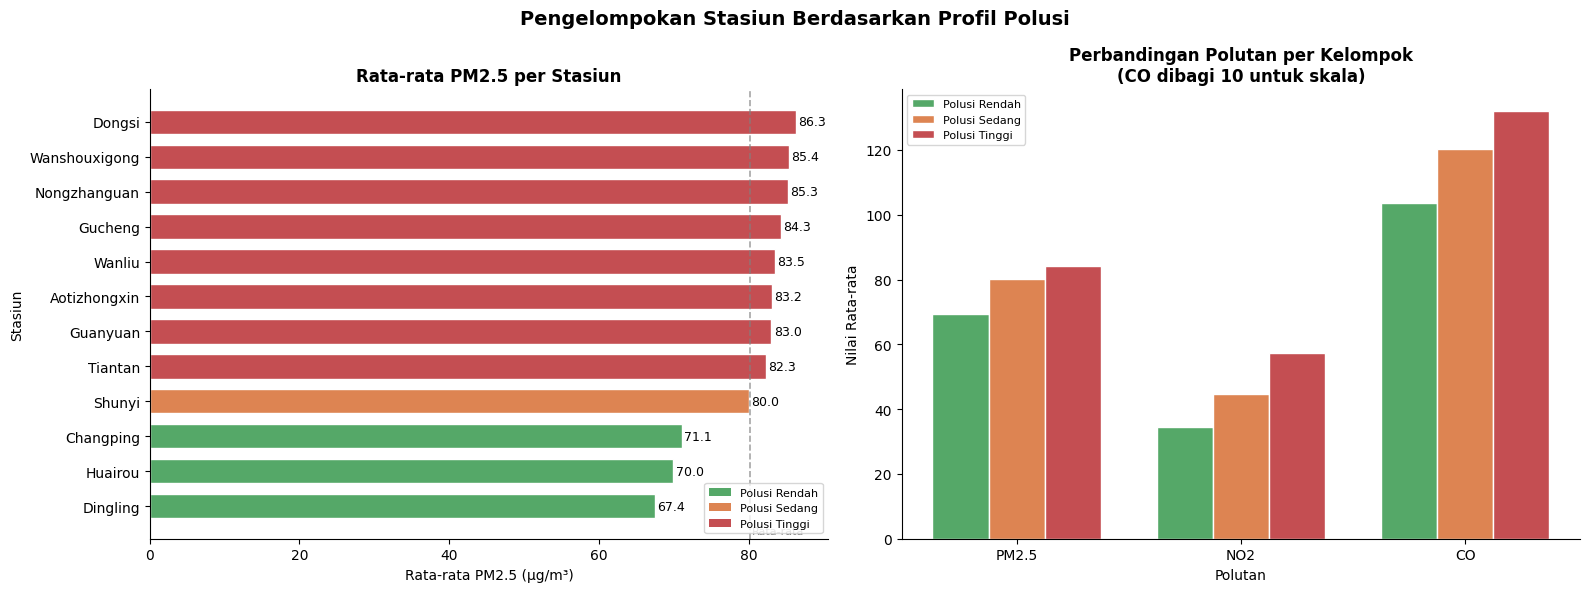

In [67]:
kelompok_colors = {
    'Polusi Rendah' : '#55A868',
    'Polusi Sedang' : '#DD8452',
    'Polusi Tinggi' : '#C44E52'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pengelompokan Stasiun Berdasarkan Profil Polusi',
             fontsize=14, fontweight='bold')

# Bar Chart PM2.5 per Stasiun
ax1 = axes[0]
station_sorted = station_profile.sort_values('PM2_5', ascending=True)
colors_bar = [kelompok_colors[str(k)] for k in station_sorted['Kelompok']]

bars = ax1.barh(station_sorted.index, station_sorted['PM2_5'],
                color=colors_bar, edgecolor='white', height=0.7)

for bar, val in zip(bars, station_sorted['PM2_5']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', ha='left', va='center', fontsize=9)

ax1.axvline(x=station_profile['PM2_5'].mean(), color='gray',
            linestyle='--', linewidth=1.2, alpha=0.7)
ax1.text(station_profile['PM2_5'].mean() + 0.3, -0.8,
         'Rata-rata', color='gray', fontsize=8)

ax1.set_title('Rata-rata PM2.5 per Stasiun', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rata-rata PM2.5 (µg/m³)', fontsize=10)
ax1.set_ylabel('Stasiun', fontsize=10)

from matplotlib.patches import Patch
legend_elem = [Patch(facecolor=c, label=l)
               for l, c in kelompok_colors.items()]
ax1.legend(handles=legend_elem, fontsize=8, loc='lower right')
sns.despine(ax=ax1)

# Grouped Bar Chart perbandingan polutan
ax2 = axes[1]
polutan = ['PM2_5', 'NO2', 'CO']
polutan_labels = ['PM2.5', 'NO2', 'CO']

x = np.arange(len(polutan_labels))
width = 0.25

kelompok_list  = list(kelompok_colors.keys())
colors_list    = list(kelompok_colors.values())

for i, (kelompok, color) in enumerate(kelompok_colors.items()):
    if kelompok not in summary.index:
        continue
    # Normalisasi nilai supaya bisa dibandingkan dalam satu chart
    vals = [
        summary.loc[kelompok, 'Rata-rata PM2.5'],
        summary.loc[kelompok, 'Rata-rata NO2'],
        summary.loc[kelompok, 'Rata-rata CO'] / 10  # dibagi 10 agar skala sebanding
    ]
    bars2 = ax2.bar(x + i * width, vals, width,
                    label=kelompok, color=color,
                    edgecolor='white')

ax2.set_title('Perbandingan Polutan per Kelompok\n(CO dibagi 10 untuk skala)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Polutan', fontsize=10)
ax2.set_ylabel('Nilai Rata-rata', fontsize=10)
ax2.set_xticks(x + width)
ax2.set_xticklabels(polutan_labels)
ax2.legend(fontsize=8)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

**Insight**
- Dengan menggunakan binning manual berdasarkan rata-rata PM2.5, stasiun dibagi menjadi 3 kelompok utama, yaitu kelompok dengan tingkat polusi rendah, sedang, dan tinggi.
- Kelompok dengan polusi rendah (<75 µg/m³) terdiri dari Changping, Huairou, dan Dingling. Selain itu nilai, nilai NO2 dan C0 pada kelompok iji juga paling rendah, menunjukkan minimnya emisi kendaraan dan industri di area tersebut. Kelompok ini terletak di pinggiran kota dengan aktivitas industri yang relatif rendah.
- Kelompok dengan polusi sedang (75-82 µg/m³) terdiri dari Shunyi yang berada di area transisi antara pusat dan pinggiran kota. Nilai NO2 dan CO berada diantara kedua kelompok lainnya
- Kelompok dengan polusi tinggi (>82 µg/m³) terdiri dari Dongsi, Wanshouxigong, Nongzhanguan, Gucheng, Wanliu, Aotizhongxin, Guanyuan, dan Tiantan. Seluruh stasiun ini berada di pusat kota Beijing dengan paparan langsung emisi kendaraan dan industri serta ditandai nilai NO2 (57) dan CO (130) tertinggi.

## Conclusion

1. **Pola Konsentrasi PM2.5 di Beijing (2013-2017)**

    Konsentrasi PM2.5 di Beijing menunjukkan pola yang fluktuatif dan belum stabil. Meskipun sempat membaik, kualitas udara tidak konsisten bertahan pada kondisi tersebut. Polusi cenderung membaik pada musim panas karena faktor cuaca yang membantu proses dispersi. Polusi cenderung terakumulasi pada malam hari ketika kondisi atmosfer lebih stabil, dan menurun pada pagi hari saat sirkulasi udara mulai membaik. Pola ini menunjukkan bahwa kualitas udara dipengaruhi oleh waktu dan aktivitas manusia.
2. **Pengaruh Kondisi Cuaca terhadap PM2.5**

    Faktor cuaca memiliki peran penting dalam menentukan tingkat polusi. Angin menjadi faktor utama yang membantu menyebarkan polutan, sementara arah angin mengindikasikan sumber polusi. Suhu turut berpengaruh melalui aktivitas manusia, sedangkan curah hujan tidak memberikan dampak signifikan. Cuaca berfungsi sebagai pengendali alami yang dapat memperburuk atau memperbaiki kualitas udara.

3. **Pengelompokan Stasiun Berdasarkan Profil Polusi**

    Hasil clustering menunjukkan bahwa stasiun pemantauan di Beijing dapat dikelompokkan menjadi tiga kategori utama, yaitu polusi rendah, sedang, dan tinggi. Pengelompokan ini mencerminkan perbedaan karakteristik wilayah secara geografis dan aktivitasnya.

    Wilayah dengan tingkat polusi rendah umumnya berada di area pinggiran dengan aktivitas yang lebih sedikit, sehingga kualitas udaranya relatif lebih baik. Sebaliknya, wilayah dengan polusi tinggi didominasi oleh area pusat kota yang memiliki intensitas aktivitas manusia, lalu lintas, dan industri yang tinggi. Adapun kelompok sedang berperan sebagai zona transisi yang menunjukkan pengaruh dari kedua kondisi tersebut.

Secara keseluruhan, polusi udara di Beijing dipengaruhi aktivitas manusia, kondisi cuacam dan karakteristik wilayah. Permasalahan polusi ini masih belum sepenuhnya terkendali. Oleh karena itu, diperlukan upaya pengendalaian yang berkelanjutan dan menyeluruh, baik kebijakan pengurangan emisi maupun pemanfaatan faktor lingkuangan secara optimal.